<a href="https://colab.research.google.com/github/nicole-kutswa/Nairobi-real-estate-analysis/blob/main/Nairobi_real_estate_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [416]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [417]:
pd.set_option("display.max_columns", None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
sns.set_style("whitegrid")

In [418]:
path= '/content/drive/MyDrive/Projects/Nairobi real estate analysis/Nairobi propertyprices - Sheet1.csv'

In [419]:
df= pd.read_csv(path)

In [420]:
df.head()

,Price,propertyType,Location,Bedroom,bathroom,House size,Land size
0,KSh 350 000 000,Townhouse,Runda,4.00,4.00,NaN,0.5 acres
1,KSh 30 000 000,Vacant Land,Karen,NaN,NaN,NaN,0.5 acres
2,KSh 325 000 000,Vacant Land,Westlands,NaN,NaN,NaN,0.5 acres
3,KSh 80 000 000,Townhouse,Kitisuru,5.00,5.00,NaN,0.5 acres
4,KSh 25 500 000,Apartment,Kileleshwa,4.00,4.00,230 m²,NaN


In [421]:
df.shape

(204, 7)

In [422]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Price         204 non-null    object 
 1   propertyType  204 non-null    object 
 2   Location      204 non-null    object 
 3   Bedroom       183 non-null    float64
 4   bathroom      181 non-null    float64
 5   House size    99 non-null     object 
 6   Land size     64 non-null     object 
dtypes: float64(2), object(5)
memory usage: 11.3+ KB


In [423]:
df.describe(include= "all")

,Price,propertyType,Location,Bedroom,bathroom,House size,Land size
count,204,204,204,183.00,181.00,99,64
unique,98,6,26,NaN,NaN,54,13
top,KSh 16 000 000,Apartment,Kilimani,NaN,NaN,150 m²,0.5 acres
freq,9,104,37,NaN,NaN,7,37
mean,NaN,NaN,NaN,3.51,2.91,NaN,NaN
std,NaN,NaN,NaN,1.59,1.63,NaN,NaN
min,NaN,NaN,NaN,1.00,1.00,NaN,NaN
25%,NaN,NaN,NaN,2.00,2.00,NaN,NaN
50%,NaN,NaN,NaN,4.00,2.00,NaN,NaN
75%,NaN,NaN,NaN,5.00,4.00,NaN,NaN


In [424]:
df= df.rename(columns = {'Price': 'price',
                         'propertyType': 'property_type',
                         'Location': 'location',
                         'Bedroom': 'bedroom',
                         'House size': 'house_size',
                         'Land size': 'land_size'})

In [425]:
df.columns

Index(['price', 'property_type', 'location', 'bedroom', 'bathroom',
       'house_size', 'land_size'],
      dtype='object')

In [426]:
df['property_type'].value_counts()

,count
property_type,
Apartment,104
Townhouse,78
Vacant Land,19
Townhuse,1
Commercial Property,1
Industrial Property,1


In [427]:
df= (
    df
    .assign(
        price = lambda x: x['price'].str.replace("KSh", "", regex= False)
        .str.replace("Ksh", "", regex= False)
        .str.replace(" ", "", regex= False)
        .str.strip()
        .astype(float)
        ,
        house_size= lambda x: x['house_size'].str.replace("m²", "", regex= False)
        .str.replace(" ", "", regex= False)
        .str.replace('"', "", regex= False)
        .str.replace("acres", "", regex= False)
        .astype(float)
        ,
        land_size= lambda x: x['land_size'].str.replace('acres', "", regex= False)
        .astype(float)
        ,
        property_type= lambda x: x['property_type'].str.replace('Townhuse', "Townhouse", regex= False)

    )
)

In [428]:
df.describe(include= "all")

,price,property_type,location,bedroom,bathroom,house_size,land_size
count,204.00,204,204,183.00,181.00,99.00,64.00
unique,NaN,5,26,NaN,NaN,NaN,NaN
top,NaN,Apartment,Kilimani,NaN,NaN,NaN,NaN
freq,NaN,104,37,NaN,NaN,NaN,NaN
mean,86383795.58,NaN,NaN,3.51,2.91,199.17,0.88
std,127089891.36,NaN,NaN,1.59,1.63,228.61,1.31
min,3500000.00,NaN,NaN,1.00,1.00,1.00,0.12
25%,14500000.00,NaN,NaN,2.00,2.00,90.00,0.50
50%,30000000.00,NaN,NaN,4.00,2.00,150.00,0.50
75%,115000000.00,NaN,NaN,5.00,4.00,226.50,0.75


In [429]:
df.isnull().sum()

,0
price,0
property_type,0
location,0
bedroom,21
bathroom,23
house_size,105
land_size,140


In [430]:
df.duplicated().sum()

np.int64(33)

In [431]:
df= df.drop_duplicates().reset_index()

In [432]:
df.duplicated().sum()

np.int64(0)

In [433]:
df.shape

(171, 8)

In [434]:
df['property_type'].unique()

array(['Townhouse', 'Vacant Land', 'Apartment', 'Commercial Property',
       'Industrial Property'], dtype=object)

In [435]:
df['house_size_indicator'] = df['house_size'].isna().astype(int)

land_or_commercial = ['Vacant Land', 'Commercial Property', 'Industrial Property']

df.loc[df['property_type'].isin(land_or_commercial), ['bedroom', 'bathroom']] = 0

df.loc[df['property_type'] == 'Apartment', 'land_size'] = 0

for col in ['bedroom', 'bathroom', 'house_size']:
    df[col] = df.groupby('property_type')[col].transform(lambda g: g.fillna(g.median()))

df['house_size'] = df['house_size'].fillna(0)
df['land_size'] = df.groupby('property_type')['land_size'].transform(lambda g: g.fillna(g.median())).fillna(0)

In [436]:
df.isnull().sum()

,0
index,0
price,0
property_type,0
location,0
bedroom,0
bathroom,0
house_size,0
land_size,0
house_size_indicator,0


In [437]:
df.describe(include= "all")

,index,price,property_type,location,bedroom,bathroom,house_size,land_size,house_size_indicator
count,171.00,171.00,171,171,171.00,171.00,171.00,171.00,171.00
unique,NaN,NaN,5,26,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Apartment,Lavington,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,92,30,NaN,NaN,NaN,NaN,NaN
mean,102.70,76606691.81,NaN,NaN,3.06,2.52,194.81,0.32,0.50
std,60.90,112204519.42,NaN,NaN,1.80,1.71,173.23,0.68,0.50
min,0.00,3500000.00,NaN,NaN,0.00,0.00,0.00,0.00,0.00
25%,48.50,13500000.00,NaN,NaN,2.00,1.00,141.00,0.00,0.00
50%,103.00,28000000.00,NaN,NaN,3.00,2.00,190.00,0.00,0.00
75%,157.50,99500000.00,NaN,NaN,4.00,4.00,228.50,0.50,1.00


In [438]:
cat_columns= df.select_dtypes(include= 'object').columns.to_list()

In [439]:
cat_columns

['property_type', 'location']

/tmp/ipykernel_778/3839445190.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, x=col, palette= "Blues_r", legend=False, order= df[col].value_counts().index)
/tmp/ipykernel_778/3839445190.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, x=col, palette= "Blues_r", legend=False, order= df[col].value_counts().index)


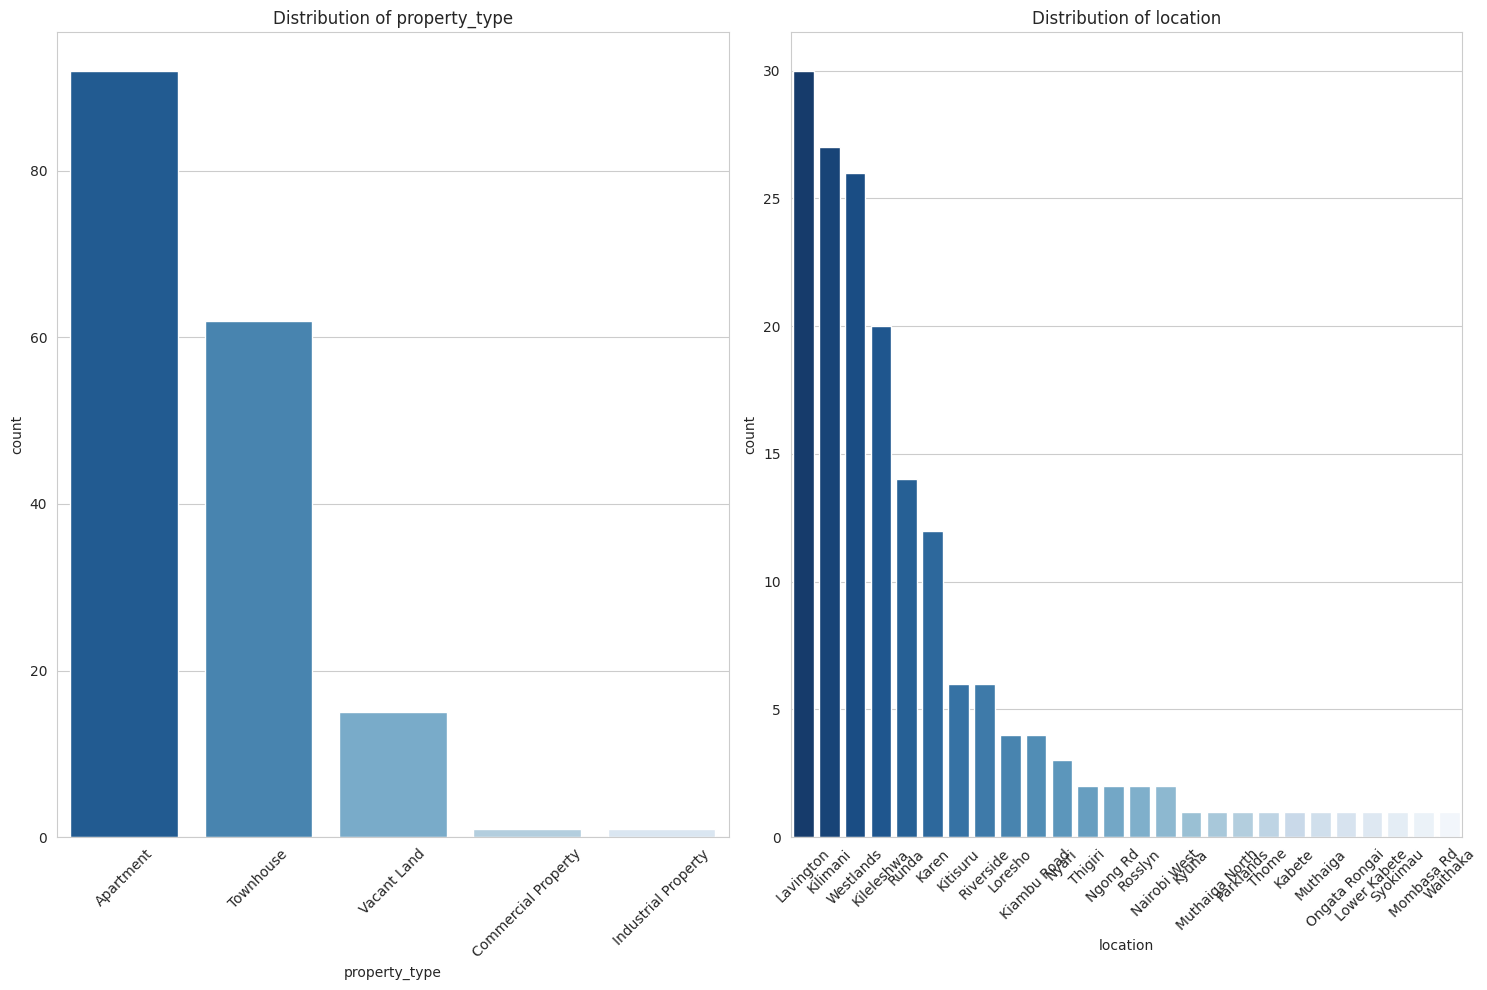

In [440]:
plt.figure(figsize= (15, 10))

for i, col in enumerate(cat_columns):
  plt.subplot(1, 2, i+1)
  sns.countplot(df, x=col, palette= "Blues_r", legend=False, order= df[col].value_counts().index)
  plt.title(f"Distribution of {col}")
  plt.xticks(rotation= 45)

plt.tight_layout()
plt.show()

In [441]:
num_col= df.select_dtypes(include=['int', 'float']).columns.to_list()
num_col

['index',
 'price',
 'bedroom',
 'bathroom',
 'house_size',
 'land_size',
 'house_size_indicator']

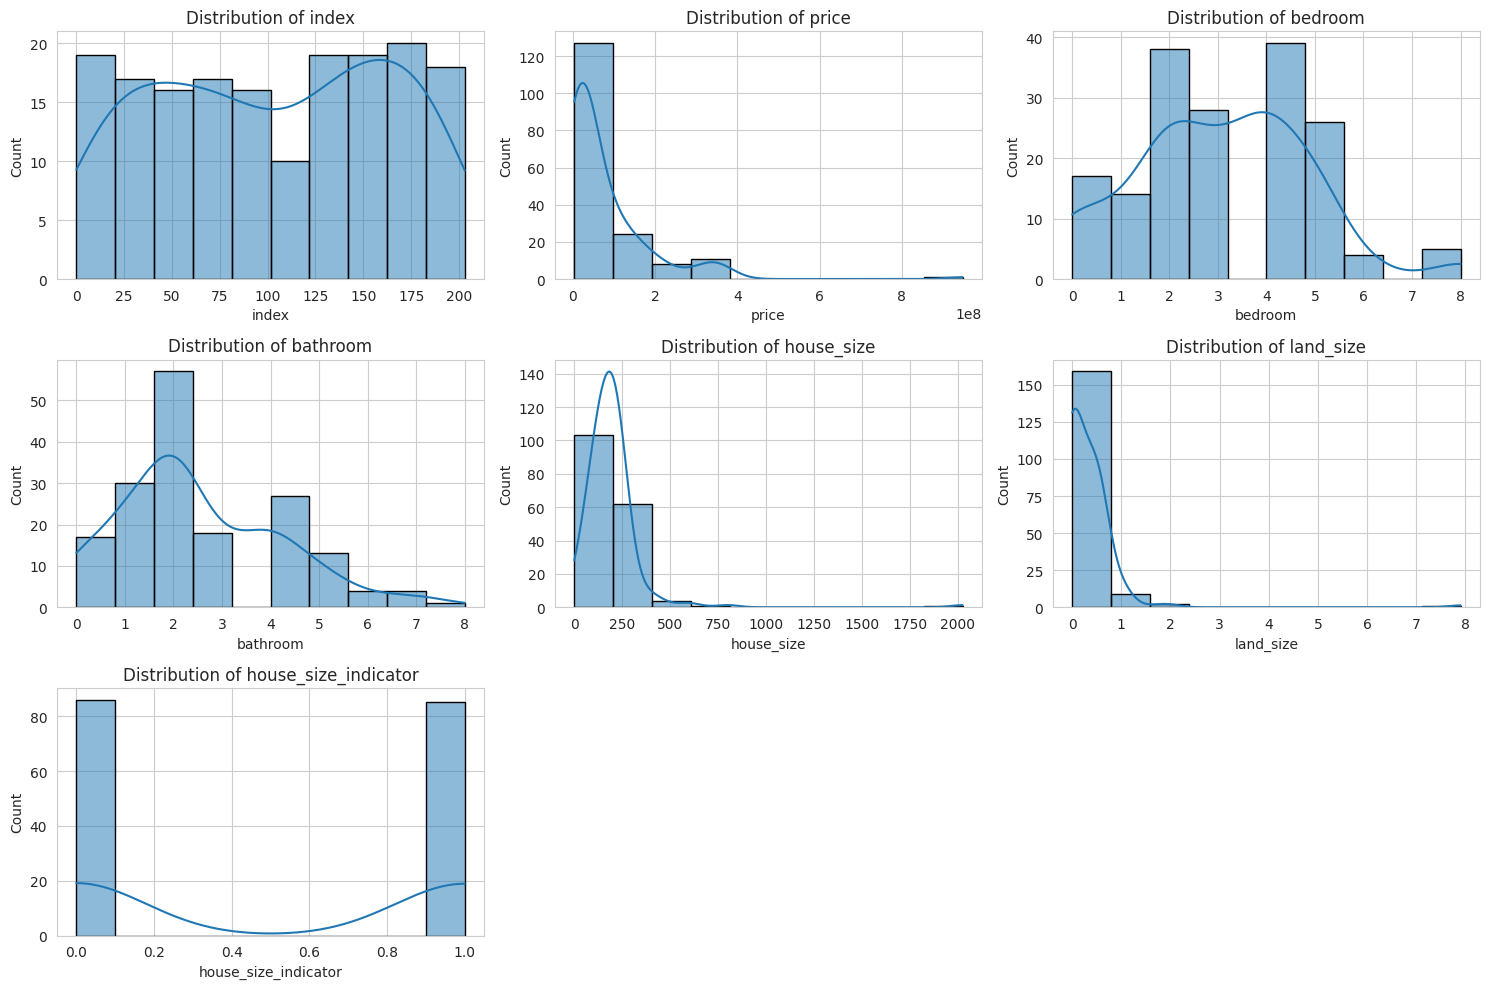

In [443]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_col):
  plt.subplot(3, 3, i+1)
  sns.histplot(df,x= col, bins= 10, kde= True, edgecolor= 'black')
  plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

In [444]:
df_fe= df.copy()

In [445]:
df_fe['price_per_m2']= (df_fe['price']/df_fe['house_size']).replace([np.inf, -np.inf], np.nan)
df_fe['total_rooms']= df_fe['bathroom']+df_fe['bedroom']
df_fe['bath_per_bed']= ((df_fe['bathroom']/df_fe['bedroom']).replace(0, np.nan)).fillna(0)
df_fe['house-land_ratio']= ((df_fe['house_size']/df_fe['land_size']).replace(0, np.nan)).fillna(0)
df_fe['log_price']= np.log1p(df_fe['price'])

In [446]:
df_fe.groupby('location')[['price', 'bath_per_bed', 'price_per_m2']].agg({
    'price': 'median',
    'price_per_m2': 'median',
    'bath_per_bed': 'mean'

}).sort_values('price_per_m2', ascending= False)

,price,price_per_m2,bath_per_bed
location,,,
Rosslyn,594000000.00,2970000.00,0.00
Runda,200000000.00,1389788.48,0.95
Muthaiga,300000000.00,1312910.28,1.00
Muthaiga North,160000000.00,700218.82,0.75
Thigiri,150000000.00,656455.14,1.12
Nyari,115000000.00,503282.28,0.93
Kabete,110000000.00,481400.44,0.40
Lower Kabete,95000000.00,415754.92,1.00
Karen,90000000.00,369803.06,0.77


In [447]:
top10_m2= (
    df_fe.groupby('location')['price_per_m2']
    .median()
    .nlargest(10)
    .dropna()
    .reset_index()
)

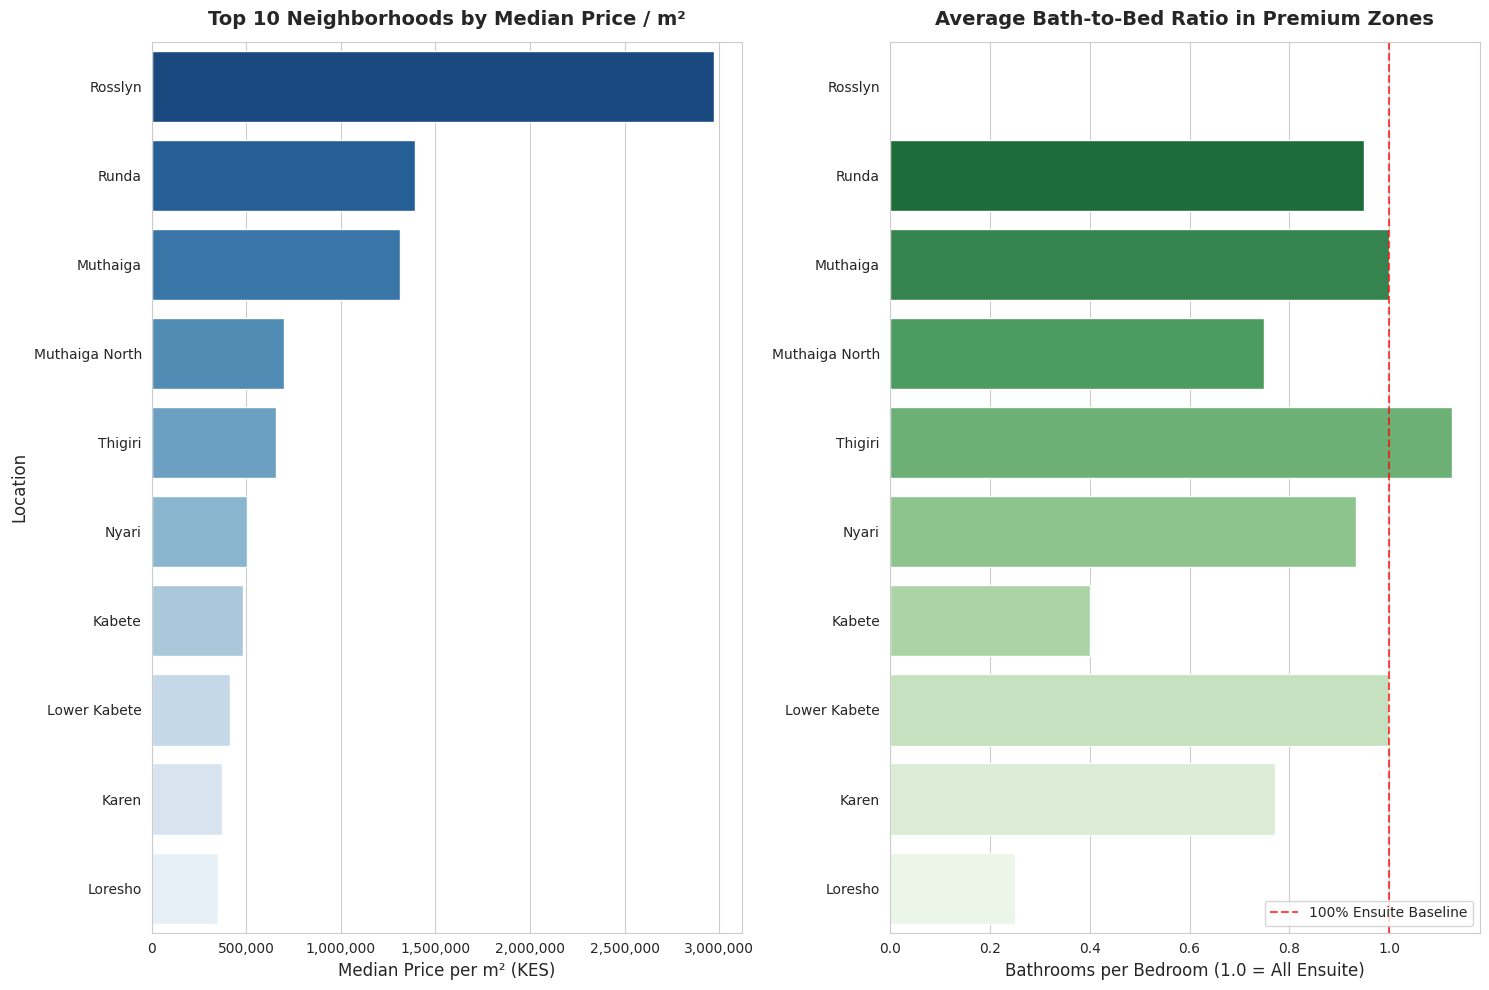

In [448]:
fig, axes= plt.subplots(1, 2, figsize=(15, 10))

sns.barplot(
    data=top10_m2,
    x='price_per_m2',
    y='location',
    ax=axes[0],
    palette='Blues_r',
    hue='location',
    legend=False
)
axes[0].set_title('Top 10 Neighborhoods by Median Price / m²', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Median Price per m² (KES)', fontsize=12)
axes[0].set_ylabel('Location', fontsize=12)

axes[0].xaxis.set_major_formatter('{x:,.0f}')

top_location= top10_m2['location'].to_list()

bath_bed_df= (
    df_fe[df_fe['location'].isin(top_location)]
    .groupby('location')['bath_per_bed']
    .mean()
    .reindex(top_location)
    .reset_index()
)

sns.barplot(
    bath_bed_df,
    x= 'bath_per_bed',
    y= 'location',
    ax= axes[1],
    palette= 'Greens_r',
    hue= 'location',
    legend= False
)

axes[1].set_title('Average Bath-to-Bed Ratio in Premium Zones', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Bathrooms per Bedroom (1.0 = All Ensuite)', fontsize=12)
axes[1].set_ylabel('')
axes[1].axvline(1.0, color='red', linestyle='--', alpha=0.7, label='100% Ensuite Baseline')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

Neighborhoods like Rosslyn, Runda, and Muthaiga dominate the KES/m² ranking, confirming that buyer capital in these areas is paying primarily for prime land positioning rather than structure volume alone.

Premium areas hover at or above the 1.0 threshold for the bath_per_bed ratio, meaning luxury homes in these blue-chip Nairobi zones almost strictly demand full en-suite configurations for every bedroom

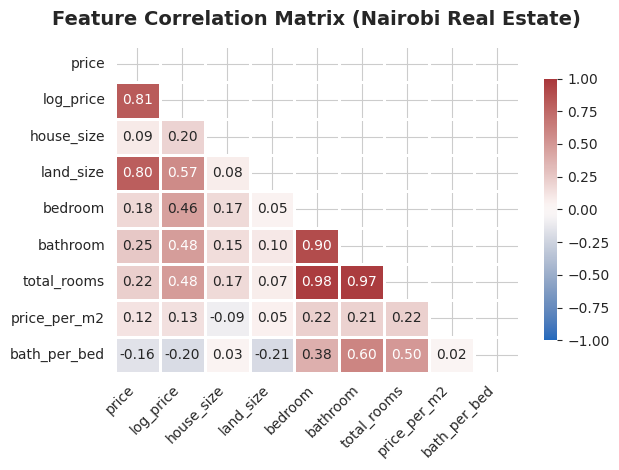

In [449]:
numeric_cols = [
    'price',
    'log_price',
    'house_size',
    'land_size',
    'bedroom',
    'bathroom',
    'total_rooms',
    'price_per_m2',
    'bath_per_bed',
    'built_to_land_ratio',
]

existing_col= [col for col in numeric_cols if col in df_fe.columns]
corr_matrix= df_fe[existing_col].corr()
mask= np.triu(np.ones_like(corr_matrix, dtype= bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='vlag',
    vmin=-1,
    vmax=1,
    linewidths=0.8,
    cbar_kws={'shrink': 0.8},
)

plt.title(
    'Feature Correlation Matrix (Nairobi Real Estate)',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [451]:
Q1= df_fe['price'].quantile(0.25)
Q3= df_fe['price'].quantile(0.75)

IQR= Q3- Q1
lower_fence= Q1-IQR*1.5
upper_fence= Q1+IQR*1.5

df_outliers= df[(df['price']<lower_fence) | (df['price']>upper_fence)]
df_outliers.shape[0]

29

In [455]:
print(f'Lower Bound: KES {lower_fence:,.2f}')
print(f'Upper Bound: KES {upper_fence:,.2f}')


Lower Bound: KES -115,500,000.00
Upper Bound: KES 142,500,000.00


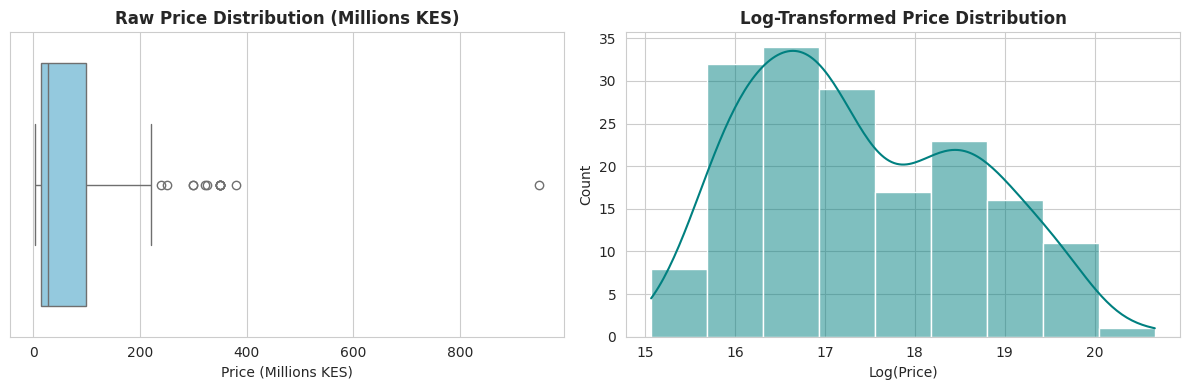

In [456]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x=df_fe['price'] / 1e6, color='skyblue')
plt.title('Raw Price Distribution (Millions KES)', fontweight='bold')
plt.xlabel('Price (Millions KES)')

plt.subplot(1, 2, 2)
sns.histplot(df_fe['log_price'], kde=True, color='teal')
plt.title('Log-Transformed Price Distribution', fontweight='bold')
plt.xlabel('Log(Price)')

plt.tight_layout()
plt.show()